In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib_venn import venn2

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

figure_dir = "figures"

# Load data

In [ ]:
adata = sc.read_h5ad("data/xenium/processed/08.1-kidney_tcr_clonal_clusters.h5ad")

In [5]:
adata.obs["sample"]

aaaombci-1output-XETG00088__0029040__Region_2__20240719__095641    XETG00088__0029040__Region_2__20240719__095641
aaapplje-1output-XETG00088__0029040__Region_2__20240719__095641    XETG00088__0029040__Region_2__20240719__095641
aabafpch-1output-XETG00088__0029040__Region_2__20240719__095641    XETG00088__0029040__Region_2__20240719__095641
aabcmlje-1output-XETG00088__0029040__Region_2__20240719__095641    XETG00088__0029040__Region_2__20240719__095641
aabecado-1output-XETG00088__0029040__Region_2__20240719__095641    XETG00088__0029040__Region_2__20240719__095641
                                                                                        ...                      
ojhmonnc-1output-XETG00088__0029040__Region_5__20240719__095642    XETG00088__0029040__Region_5__20240719__095642
ojhngikd-1output-XETG00088__0029040__Region_5__20240719__095642    XETG00088__0029040__Region_5__20240719__095642
ojibodbj-1output-XETG00088__0029040__Region_5__20240719__095642    XETG00088__0029040__R

In [6]:
tmp = adata.copy()
v_genes_toremove = ["TRGV11", "TRGV5P", "TRGVA", "TRGVB"]
tmp = tmp[:, ~tmp.var_names.isin(v_genes_toremove)]
# only concentrate on the vgenes
av = [x for x in tmp.var_names if x.startswith("TRAV")]
bv = [x for x in tmp.var_names if x.startswith("TRBV")]
gv = [x for x in tmp.var_names if x.startswith("TRGV")]
dv = [x for x in tmp.var_names if x.startswith("TRDV")]

In [ ]:
cond_dic = {
    "Control": [
        "XETG00088__0029040__Region_2__20240719__095641",
        "XETG00088__0029040__Region_3__20240719__095641",
        "XETG00088__0029041__Region_1__20240719__095642",
    ],
    "ANCA": [
        "XETG00088__0029040__Region_4__20240719__095642",
        "XETG00088__0029040__Region_5__20240719__095642",
        "XETG00088__0029040__Region_6__20240719__095642",
        "XETG00088__0029040__Region_7__20240719__095642",
        "XETG00088__0029041__Region_3__20240719__095642",
        "XETG00088__0029041__Region_4__20240719__095642",
        "XETG00088__0029041__Region_5__20240719__095642",
        "XETG00088__0029041__Region_6__20240719__095642",
        "XETG00088__0029041__Region_7__20240719__095642",
        "XETG00088__0029041__Region_8__20240719__095642",
    ],
    "BK-Virus": ["XETG00088__0029041__Region_2__20240719__095642"],
}
inverted_dict = {
    sample_id: condition
    for condition, sample_ids in cond_dic.items()
    for sample_id in sample_ids
}
tmp.obs["condition"] = tmp.obs["sample"].astype(str).replace(inverted_dict)
adata.obs["condition"] = adata.obs["sample"].astype(str).replace(inverted_dict)

/tmp/ipykernel_1430/4111220040.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  tmp.obs["condition"] = tmp.obs["sample"].astype(str).replace(inverted_dict)


In [8]:
realt = ["CD4+", "CD8+", "MAIT", "NK/NKT", "TFH", "Tregs", "gdT"]
tmp = tmp[tmp.obs.tcell_subtype.isin(realt)]

# Looking for gd T cells blind with masking.

In [9]:
gdgenes = ["TRDC"] + dv  # +gv,"TRGC1","TRGC2"
abgenes = ["TRAC", "TRBC1", "TRBC2"] + bv + av

In [10]:
# tmp_pp = tmp.copy()
# sc.pp.normalize_total(tmp_pp)
# # Logarithmize the data
# sc.pp.log1p(tmp_pp)

In [11]:
sc.tl.score_genes(tmp, gene_list=gdgenes, score_name="GDscore")
sc.tl.score_genes(tmp, gene_list=abgenes, score_name="ABscore")

/data/bonn-epyc/projects/cedric/envs/kub_spatialTCR/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:165: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


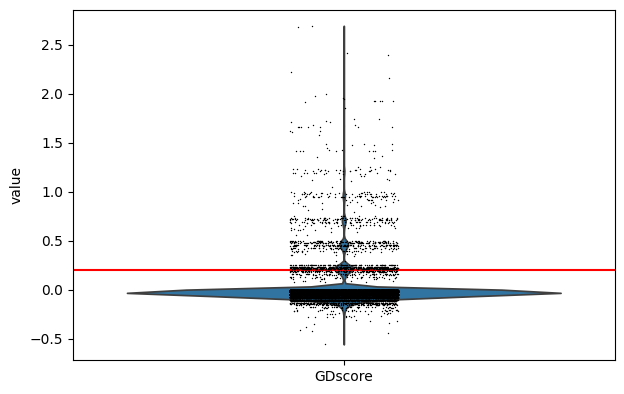

1384 20033 0.06908600808665702


In [12]:
sc.pl.violin(tmp, ["GDscore"], size=1, show=False)
plt.axhline(0.2, c="r")
plt.show()
plt.close()
print(
    (tmp.obs.GDscore > 0.2).sum(),
    tmp.shape[0],
    (tmp.obs.GDscore > 0.2).sum() / tmp.shape[0],
)

In [13]:
tmp.obs["gdT_byscore"] = tmp.obs.GDscore > 0.2
adata.obs["tcell_subtype_redefine_gdT"] = adata.obs["tcell_subtype"]
adata.obs.loc[tmp[tmp.obs.gdT_byscore].obs.index, "tcell_subtype_redefine_gdT"] = "gdT"

In [14]:
# adata.write_h5ad("08-kidney_tcr_clonal_clusters_redefine_gdT.h5ad")

# compare new gdT cells with remaining old gdT cells

In [15]:
newmask = tmp.obs.gdT_byscore
oldmask = tmp.obs.tcell_subtype == "gdT"
mask = np.logical_or(newmask, oldmask)

In [16]:
# oldvsnew gd Tcells
ovngd = tmp[mask].copy()

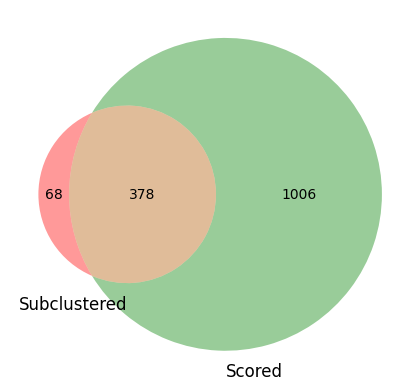

In [17]:
old = set(ovngd[ovngd.obs.tcell_subtype == "gdT"].obs.index)
new = set(ovngd[ovngd.obs.gdT_byscore].obs.index)
venn2((old, new), ["Subclustered", "Scored"])
plt.show()

# TRV completeness

In [ ]:
def normalized_fraction_ofTRVchains(tmp, av, bv, normalized=True):
    # Create binary masks for the presence of the genes in the lists
    av_mask = tmp[:, av].X.sum(axis=1) > 0
    bv_mask = tmp[:, bv].X.sum(axis=1) > 0

    # Determine categories for each cell
    category = np.zeros(av_mask.shape, dtype=int)
    category[(av_mask == True) & (bv_mask == True)] = 1
    category[(av_mask == True) & (bv_mask == False)] = 2
    category[(av_mask == False) & (bv_mask == True)] = 3
    category[(av_mask == False) & (bv_mask == False)] = 4

    # Count the number of cells in each category
    category_counts_t = [
        np.sum(category == 1),
        np.sum(category == 2),
        np.sum(category == 3),
        np.sum(category == 4),
    ]
    if normalized:
        return pd.Series(category_counts_t) / pd.Series(category_counts_t).sum()
    else:
        return pd.Series(category_counts_t)  # /pd.Series(category_counts_t).sum()

In [19]:
cc_old = normalized_fraction_ofTRVchains(
    ovngd[~ovngd.obs.gdT_byscore.astype(bool)], gv, dv
)
cc_new = normalized_fraction_ofTRVchains(
    ovngd[ovngd.obs.tcell_subtype != "gdT"], gv, dv
)
cc_inter = normalized_fraction_ofTRVchains(
    ovngd[
        np.logical_and(
            ovngd.obs.tcell_subtype == "gdT", ovngd.obs.gdT_byscore.astype(bool)
        )
    ],
    gv,
    dv,
)

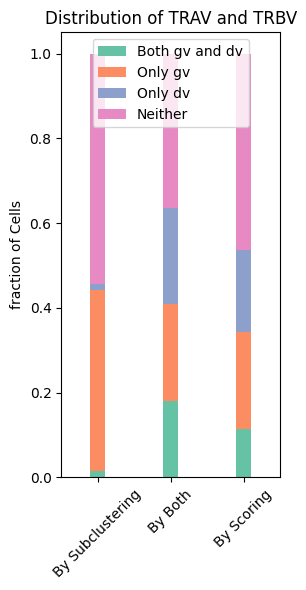

In [ ]:
# Labels for the pie chart
labels = ["Both gv and dv", "Only gv", "Only dv", "Neither"]
# Define colors (customize as needed)
colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]  # Green, Orange, Blue, Pink

# Create the bar plot
fig, ax = plt.subplots(figsize=(3, 6))
oldbottom, interbottom, newbottom = 0, 0, 0
bars = []
for k in range(len(labels)):
    bars.append(ax.bar(0, cc_old[k], 0.4, bottom=oldbottom, color=colors[k]))
    oldbottom += cc_old[k]
    ax.bar(2, cc_inter[k], 0.4, bottom=interbottom, color=colors[k])
    interbottom += cc_inter[k]
    ax.bar(4, cc_new[k], 0.4, bottom=newbottom, color=colors[k])
    newbottom += cc_new[k]


ax.legend([b[0] for b in bars], labels, loc="upper center")
# Add legend
# ax.legend(labels, loc="upper right")

# Labels and title
ax.set_ylabel("fraction of Cells")
ax.set_title("Distribution of TRAV and TRBV")
# plt.xticks([0,1,2],["CD4+ T cells", "CD8+ T cells","GD T cells"])
plt.xticks([0, 2, 4], ["By Subclustering", "By Both", "By Scoring"], rotation=45)

# Show plot
plt.xlim(-1, 5)
plt.tight_layout()
plt.savefig(f"{figure_dir}/stacked_gvdv.png", dpi=300)

# Repertoire Donut

In [ ]:
def get_dominant_v(tmp, vgenes):
    array = tmp[:, vgenes].X.toarray()
    max_indices = np.argmax(array, axis=1)
    max_values = array[np.arange(array.shape[0]), max_indices]
    # pdb.set_trace()
    sorted_rows = np.sort(array, axis=1)[:, -2:]
    ties = sorted_rows[:, 0] == sorted_rows[:, 1]
    result = np.where(ties, -1, max_indices)
    # pdb.set_trace()
    return [vgenes[i] if i != -1 else "None" for i in result]

In [ ]:
import matplotlib.colors as mcolors


def blend_colors(base_color, mix_color, ratio):
    base_rgb = np.array(mcolors.to_rgb(base_color))
    mix_rgb = np.array(mcolors.to_rgb(mix_color))
    blended_rgb = (1 - ratio) * base_rgb + ratio * mix_rgb
    return blended_rgb

In [28]:
new = ovngd[ovngd.obs.tcell_subtype != "gdT"].copy()
new.obs["GV"] = get_dominant_v(new, gv)
new.obs["DV"] = get_dominant_v(new, dv)
newrep = (
    new[np.all(new.obs[["GV", "DV"]] != "None", 1)].obs[["GV", "DV"]].value_counts()
)
newrep, newrep.sum()

(GV      DV   
 TRGV3   TRDV1    18
 TRGV9   TRDV2    12
 TRGV4   TRDV1     8
 TRGV10  TRDV1     6
 TRGV2   TRDV1     5
         TRDV2     4
 TRGV9   TRDV1     4
 TRGV3   TRDV2     4
         TRDV3     3
 TRGV8   TRDV1     3
 TRGV7   TRDV2     2
         TRDV1     2
 TRGV5   TRDV2     2
         TRDV1     2
 TRGV6   TRDV1     2
 TRGV2   TRDV3     1
 TRGV1   TRDV1     1
         TRDV2     1
 TRGV5   TRDV3     1
 TRGV4   TRDV2     1
 TRGV8   TRDV3     1
         TRDV2     1
 Name: count, dtype: int64,
 np.int64(84))

In [43]:
old = ovngd[ovngd.obs.tcell_subtype == "gdT"].copy()
old.obs["GV"] = get_dominant_v(old, gv)
old.obs["DV"] = get_dominant_v(old, dv)
oldrep = (
    old[np.all(old.obs[["GV", "DV"]] != "None", 1)].obs[["GV", "DV"]].value_counts()
)
oldrep, oldrep.sum(), old.shape

(GV      DV   
 TRGV9   TRDV2    17
 TRGV8   TRDV1     5
 TRGV10  TRDV2     3
 TRGV3   TRDV2     2
 TRGV4   TRDV2     2
 TRGV10  TRDV1     2
 TRGV2   TRDV1     2
         TRDV2     2
 TRGV3   TRDV1     2
 TRGV1   TRDV3     1
         TRDV2     1
 TRGV3   TRDV3     1
 TRGV2   TRDV3     1
 TRGV10  TRDV3     1
 TRGV5   TRDV2     1
 TRGV7   TRDV2     1
 TRGV8   TRDV2     1
 TRGV9   TRDV1     1
         TRDV3     1
 Name: count, dtype: int64,
 np.int64(47),
 (446, 432))

In [31]:
ovngd.obs["GV"] = get_dominant_v(ovngd, gv)
ovngd.obs["DV"] = get_dominant_v(ovngd, dv)
allrep = (
    ovngd[np.all(ovngd.obs[["GV", "DV"]] != "None", 1)].obs[["GV", "DV"]].value_counts()
)
allrep, allrep.sum()

(GV      DV   
 TRGV9   TRDV2    29
 TRGV3   TRDV1    20
 TRGV4   TRDV1     8
 TRGV8   TRDV1     8
 TRGV10  TRDV1     8
 TRGV2   TRDV1     7
 TRGV3   TRDV2     6
 TRGV2   TRDV2     6
 TRGV9   TRDV1     5
 TRGV3   TRDV3     4
 TRGV7   TRDV2     3
 TRGV10  TRDV2     3
 TRGV5   TRDV2     3
 TRGV4   TRDV2     3
 TRGV1   TRDV2     2
 TRGV8   TRDV2     2
 TRGV5   TRDV1     2
 TRGV2   TRDV3     2
 TRGV7   TRDV1     2
 TRGV6   TRDV1     2
 TRGV1   TRDV1     1
 TRGV10  TRDV3     1
 TRGV1   TRDV3     1
 TRGV5   TRDV3     1
 TRGV8   TRDV3     1
 TRGV9   TRDV3     1
 Name: count, dtype: int64,
 np.int64(131))

In [32]:
# Define mix colors
purple = "purple"
orange = "orange"

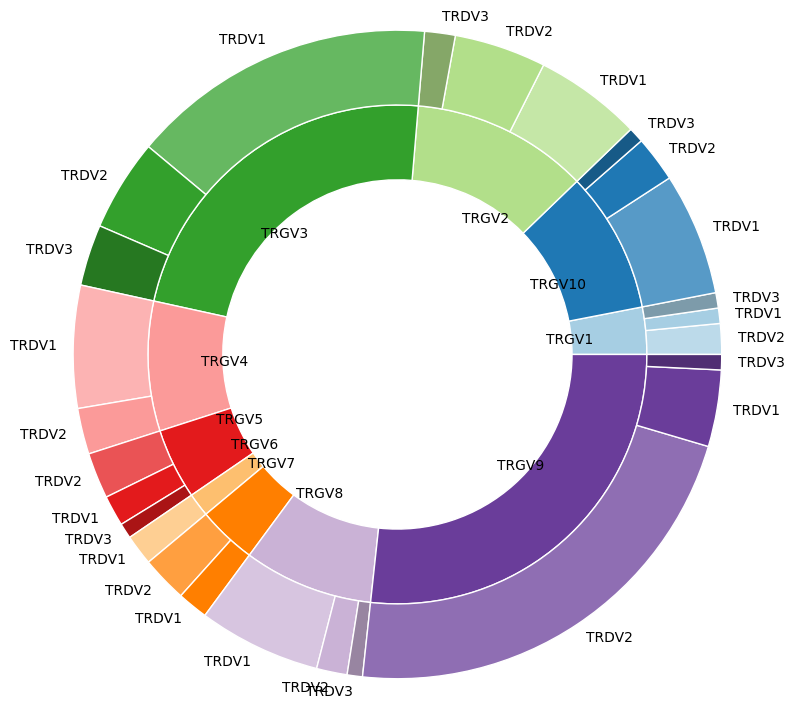

In [ ]:
white = "#FFFFFF"
black = "#000000"
light_ratio = 0.25

counts = allrep.copy()
# Aggregate for inner ring
trav_counts = counts.groupby(level="GV").sum()

# Prepare figure
fig, ax = plt.subplots(figsize=(8, 8))

# Inner ring (TRAV)
inner_colors = plt.cm.Paired.colors[: len(trav_counts)]
ax.pie(
    trav_counts,
    radius=1,
    labels=trav_counts.index,
    labeldistance=0.6,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer ring (TRBV), with exploded effect
# Get angles for each wedge to shift them
outer_labels = []
outer_sizes = []
outer_colors = []

start_angle = 0
for i, (trav, inner_val) in enumerate(trav_counts.items()):
    sub = counts[trav]
    angle = (inner_val / counts.sum()) * 360

    for j, (trbv, val) in enumerate(sub.items()):
        if j == 0:
            color = blend_colors(
                inner_colors[i], white, light_ratio
            )  # Slightly lighter
        elif j == 1:
            color = inner_colors[i]  # Keep original
        else:
            color = blend_colors(inner_colors[i], black, light_ratio)  # Slightly darker

        outer_labels.append(trbv)
        outer_sizes.append(val)
        outer_colors.append(color)

    start_angle += angle

# Plot outer ring
wedges, _ = ax.pie(
    outer_sizes,
    radius=1.3,
    labels=outer_labels,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Shift each wedge outward a bit (manual explode simulation)
for w in wedges:
    ang = (w.theta2 + w.theta1) / 2.0
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    w.set_center((0.0 * x, 0.0 * y))  # Shift outward

# Final layout
ax.set(aspect="equal")
# plt.title("Nested Pie with Exploded Outer Ring (by TRAV)")
plt.tight_layout()
# plt.show()
plt.savefig(f"{figure_dir}/GDRepertoire_allscoringAndCluster.pdf", dpi=300)

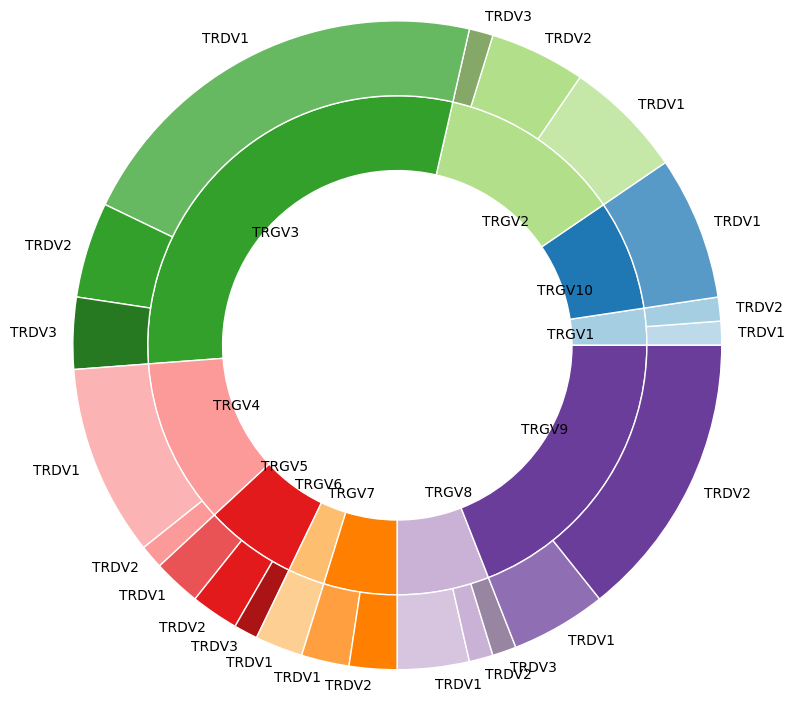

In [ ]:
counts = newrep.copy()
trav_counts = counts.groupby(level="GV").sum()
# Prepare figure
fig, ax = plt.subplots(figsize=(8, 8))

# Inner ring (TRAV)
inner_colors = plt.cm.Paired.colors[: len(trav_counts)]
ax.pie(
    trav_counts,
    radius=1,
    labels=trav_counts.index,
    labeldistance=0.6,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer ring (TRBV), with exploded effect
# Get angles for each wedge to shift them
outer_labels = []
outer_sizes = []
outer_colors = []

start_angle = 0
for i, (trav, inner_val) in enumerate(trav_counts.items()):
    sub = counts[trav].sort_index()
    angle = (inner_val / counts.sum()) * 360

    for j, (trbv, val) in enumerate(sub.items()):
        if j == 0:
            color = blend_colors(
                inner_colors[i], white, light_ratio
            )  # Slightly lighter
        elif j == 1:
            color = inner_colors[i]  # Keep original
        else:
            color = blend_colors(inner_colors[i], black, light_ratio)  # Slightly darker

        outer_labels.append(trbv)
        outer_sizes.append(val)
        outer_colors.append(color)

    start_angle += angle

# Plot outer ring
wedges, _ = ax.pie(
    outer_sizes,
    radius=1.3,
    labels=outer_labels,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Shift each wedge outward a bit (manual explode simulation)
for w in wedges:
    ang = (w.theta2 + w.theta1) / 2.0
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    w.set_center((0.0 * x, 0.0 * y))  # Shift outward

# Final layout
ax.set(aspect="equal")
# plt.title("Nested Pie with Exploded Outer Ring (by TRAV)")
plt.tight_layout()
plt.savefig(f"{figure_dir}/Supp04_GDRepertoire_ExclusiveScoring.pdf", dpi=300)

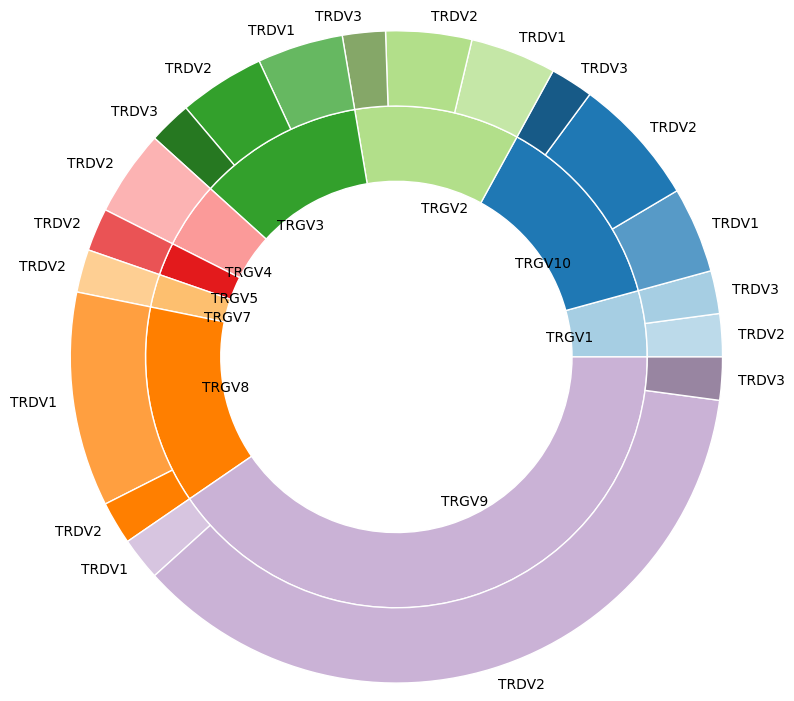

In [ ]:
counts = oldrep.copy()
trav_counts = counts.groupby(level="GV").sum()
# Prepare figure
fig, ax = plt.subplots(figsize=(8, 8))

# Inner ring (TRAV)
inner_colors = plt.cm.Paired.colors[: len(trav_counts)]
ax.pie(
    trav_counts,
    radius=1,
    labels=trav_counts.index,
    labeldistance=0.6,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer ring (TRBV), with exploded effect
# Get angles for each wedge to shift them
outer_labels = []
outer_sizes = []
outer_colors = []

start_angle = 0
for i, (trav, inner_val) in enumerate(trav_counts.items()):
    sub = counts[trav].sort_index()
    angle = (inner_val / counts.sum()) * 360

    for j, (trbv, val) in enumerate(sub.items()):
        if j == 0:
            color = blend_colors(
                inner_colors[i], white, light_ratio
            )  # Slightly lighter
        elif j == 1:
            color = inner_colors[i]  # Keep original
        else:
            color = blend_colors(inner_colors[i], black, light_ratio)  # Slightly darker

        outer_labels.append(trbv)
        outer_sizes.append(val)
        outer_colors.append(color)

    start_angle += angle

# Plot outer ring
wedges, _ = ax.pie(
    outer_sizes,
    radius=1.3,
    labels=outer_labels,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Shift each wedge outward a bit (manual explode simulation)
for w in wedges:
    ang = (w.theta2 + w.theta1) / 2.0
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    w.set_center((0.0 * x, 0.0 * y))  # Shift outward

# Final layout
ax.set(aspect="equal")
# plt.title("Nested Pie with Exploded Outer Ring (by TRAV)")
plt.tight_layout()
plt.savefig(f"{figure_dir}/Supp04_GDRepertoire_ExclusiveSubclustered.pdf", dpi=300)